In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
region_direction_map = {
    "BRA": "decrease",
    "CAN": "increase",
    "CIS": "increase",
    "IND": "increase",
    "TUR": "decrease",
    "XAF": "increase",
    "XE25": "increase",
    "XNF": "decrease"}

In [30]:
def plot_kappa_17regions(csv_path, out_png, region_direction_map):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # ---------- 1. 读 CSV ----------
    df = pd.read_csv(csv_path)

    # 排序（保证时间顺序）
    df = df.sort_values(["region", "mode", "year"])

    # ★ 获取 CSV 中所有地区（保证 GLOBAL 在最后）
    all_regions = sorted(df["region"].unique().tolist())
    if "GLOBAL" in all_regions:
        all_regions.remove("GLOBAL")
        all_regions.append("GLOBAL")
    n = len(all_regions)

    # ---------- 2. 子图布局 ----------
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(16, 12),
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    # ---------- 3. 逐地域画图 ----------
    for i, reg in enumerate(all_regions):
        ax = axes[i]
        
        # ★ 只有在 region_direction_map 中的地区才画图
        if reg in region_direction_map.keys() or reg=="GLOBAL":
            d_reg = df[df["region"] == reg]

            # Basin
            d_basin = d_reg[d_reg["mode"] == "basin"]
            ax.plot(
                d_basin["year"],
                d_basin["kappa"],
                color="blue",
                label="Basin",
                linewidth=2
            )

            # Region
            d_region = d_reg[d_reg["mode"] == "region"]
            ax.plot(
                d_region["year"],
                d_region["kappa"],
                color="red",
                label="Region",
                linewidth=2
            )

            ax.set_title(reg)
            ax.set_ylim(0, 1.2)
            ax.grid(alpha=0.3)
        else:
            # ★ 非 mapping 中的地区显示为空白
            ax.set_title(reg)
            ax.set_ylim(0, 1.2)

        # 行列位置
        row = i // ncols
        col = i % ncols

        # y 轴：只在最左列显示
        if col == 0:
            ax.set_ylabel("Kappa", fontsize=14)
            ax.tick_params(axis="y", labelleft=True)
        else:
            ax.tick_params(axis="y", labelleft=False)

        # x 轴：只在最后一行显示
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=14)
            ax.tick_params(axis="x", labelbottom=True)
        else:
            ax.tick_params(axis="x", labelbottom=False)
        # ---------- 删除多余子图 ----------
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    # ---------- 4. 公共 legend ----------
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower right",
        ncol=2,
        fontsize=20
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.show()

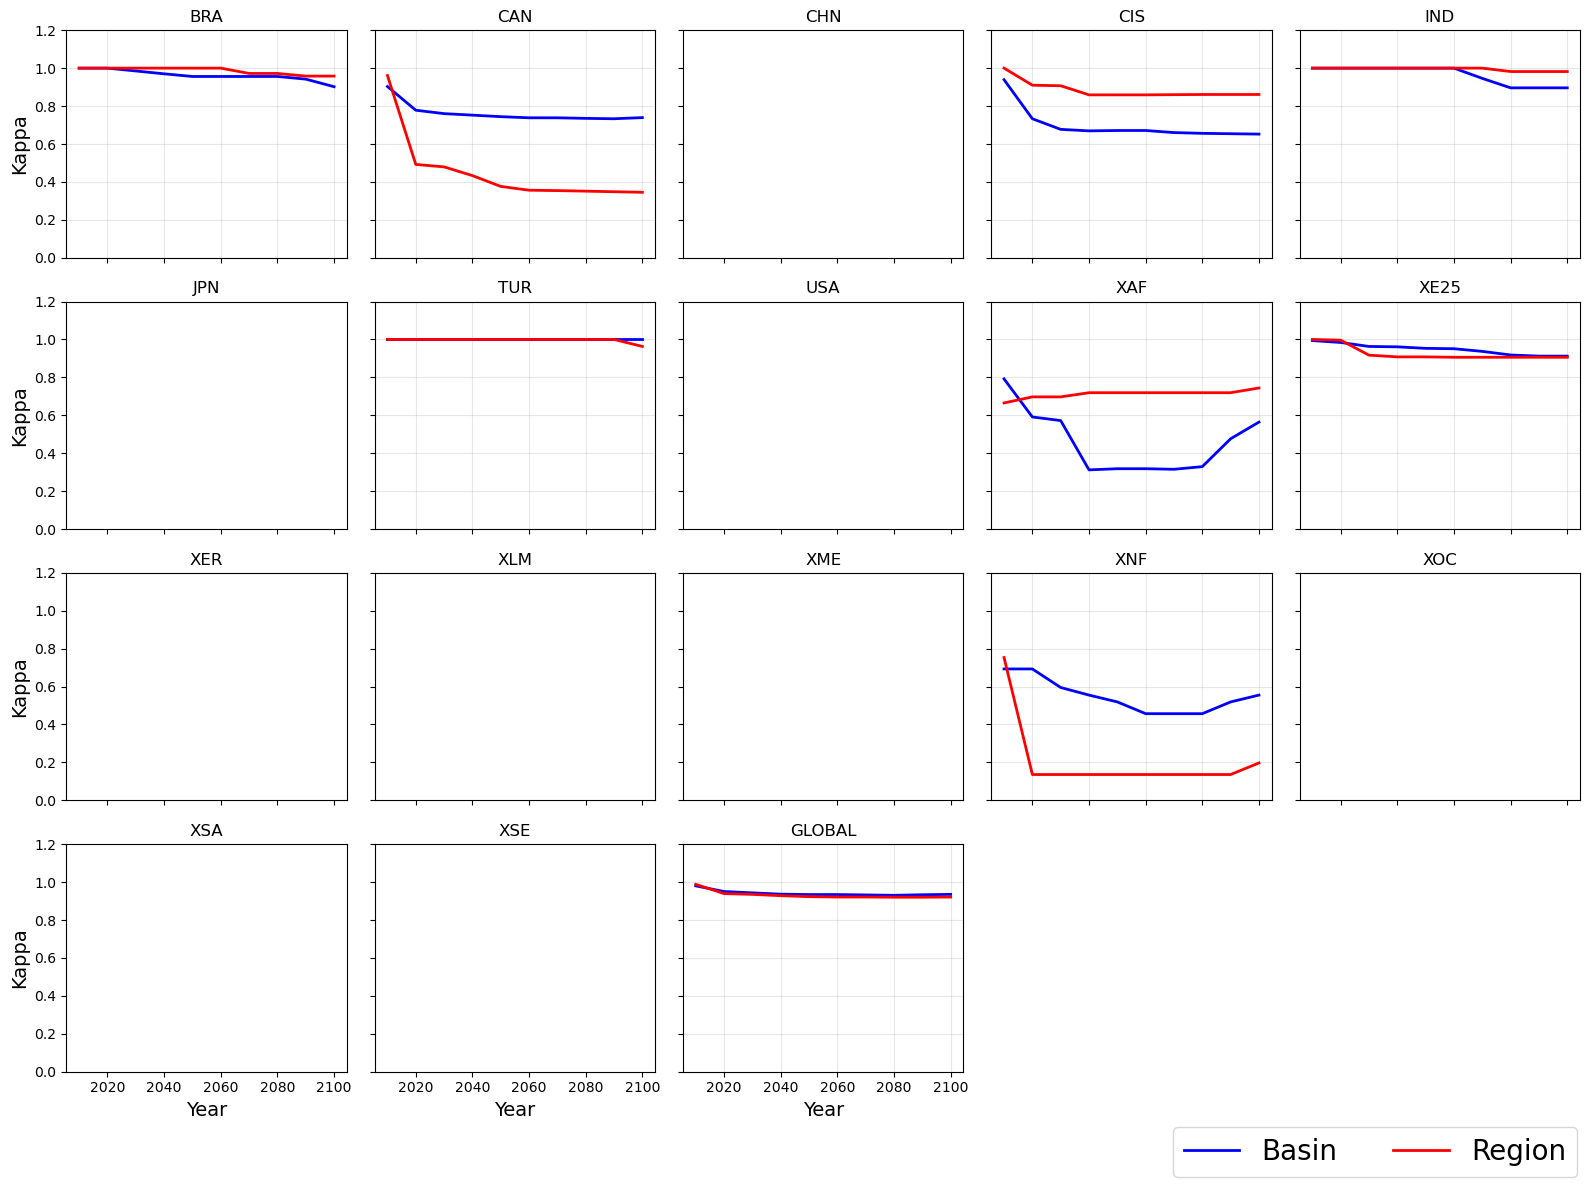

In [31]:
plot_kappa_17regions(
    csv_path="../../CSV/kappa/kappa_agri_consistent_vs2005_.csv",
    out_png="../../plot/kappa/17+1regions_kappa_compare_to_2005_consistent.png",
    region_direction_map=region_direction_map
)